# Fase 1 — Análise Descritiva: Candidatos 2026 (TSE)

Esta fase é **exploração pura**: olhar para os dados de candidatos e de bens declarados sem nenhum compromisso com o que vem depois (clusterização, regras de associação, anomalias). A ideia é conhecer o dataset por conta própria — distribuições, proporções, outliers, relações entre variáveis — **antes** de qualquer modelo apontar o que "importa". As fases seguintes vão te pedir pra escolher variáveis; essa escolha deve nascer do que você observar aqui, não o contrário.

Este notebook parte do arquivo salvo pela **Fase 0** (`00_preparacao_dados.ipynb`).

## Configuração

In [11]:
CARGO = "DEPUTADO FEDERAL"   
UF = ["AL","BA","CE","MA","PB","PE","PI","RN","SE" ]  
ANO_ELEICAO = 2026

In [12]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
pd.set_option('display.max_columns', None)
pd.set_option("display.float_format", "{:,.2f}".format)

nome_uf = UF if UF is not None else 'BRASIL'
nome_cargo = CARGO.replace(' ', '_')
arquivo = f"dados/candidatos_{nome_cargo}_nordeste_{ANO_ELEICAO}.csv"

df = pd.read_csv(arquivo)
print(f"Carregado: {arquivo}  ->  {df.shape[0]} candidatos, {df.shape[1]} colunas")
df.head()

Carregado: dados/candidatos_DEPUTADO_FEDERAL_nordeste_2026.csv  ->  2189 candidatos, 59 colunas


,DT_GERACAO,HH_GERACAO,ANO_ELEICAO,CD_TIPO_ELEICAO,NM_TIPO_ELEICAO,NR_TURNO,CD_ELEICAO,DS_ELEICAO,DT_ELEICAO,TP_ABRANGENCIA,SG_UF,SG_UE,NM_UE,CD_CARGO,DS_CARGO,SQ_CANDIDATO,NR_CANDIDATO,NM_CANDIDATO,NM_URNA_CANDIDATO,NM_SOCIAL_CANDIDATO,NR_CPF_CANDIDATO,DS_EMAIL,CD_SITUACAO_CANDIDATURA,DS_SITUACAO_CANDIDATURA,TP_AGREMIACAO,NR_PARTIDO,SG_PARTIDO,NM_PARTIDO,NR_FEDERACAO,NM_FEDERACAO,SG_FEDERACAO,DS_COMPOSICAO_FEDERACAO,SQ_COLIGACAO,NM_COLIGACAO,DS_COMPOSICAO_COLIGACAO,SG_UF_NASCIMENTO,DT_NASCIMENTO,NR_TITULO_ELEITORAL_CANDIDATO,CD_GENERO,DS_GENERO,CD_GRAU_INSTRUCAO,DS_GRAU_INSTRUCAO,CD_ESTADO_CIVIL,DS_ESTADO_CIVIL,CD_COR_RACA,DS_COR_RACA,CD_OCUPACAO,DS_OCUPACAO,CD_SIT_TOT_TURNO,DS_SIT_TOT_TURNO,BENS IMÓVEIS,BENS MÓVEIS,DINHEIRO,INVESTIMENTOS RENDA FIXA,INVESTIMENTOS RENDA VARIÁVEL,OUTROS BENS,Total_Bens,Total_Bens_Log,IDADE
0,23/08/2026,19:30:42,2026,2,ELEIÇÃO ORDINÁRIA,1,6259,Eleições Gerais Estaduais 2026,2026-10-04,ESTADUAL,AL,AL,ALAGOAS,6,DEPUTADO FEDERAL,20002532430,3033,CAROLAYNNE PIRES DE OLIVEIRA SOUZA,CAROL SOUZA,#NULO,10279565488,NÃO DIVULGÁVEL,-3,#NE,PARTIDO ISOLADO,30,NOVO,PARTIDO NOVO,-1,#NULO,#NULO,#NULO,20001800111,PARTIDO ISOLADO,NOVO,AL,1991-11-10,40248081791,4,FEMININO,8,SUPERIOR COMPLETO,1,SOLTEIRO(A),2,PRETA,132,PSICÓLOGO,-1,#NULO,NaN,NaN,NaN,NaN,NaN,NaN,0.00,0.00,34
1,23/08/2026,19:30:42,2026,2,ELEIÇÃO ORDINÁRIA,1,6259,Eleições Gerais Estaduais 2026,2026-10-04,ESTADUAL,AL,AL,ALAGOAS,6,DEPUTADO FEDERAL,20002532431,3030,JOSÉ GUIDO DO RÊGO SANTOS NETO,GUIDO SANTOS,#NULO,5955901442,NÃO DIVULGÁVEL,-3,#NE,PARTIDO ISOLADO,30,NOVO,PARTIDO NOVO,-1,#NULO,#NULO,#NULO,20001800111,PARTIDO ISOLADO,NOVO,AL,1985-06-07,31724561767,2,MASCULINO,8,SUPERIOR COMPLETO,3,CASADO(A),1,BRANCA,296,SERVIDOR PÚBLICO FEDERAL,-1,#NULO,0.00,0.00,"45,000.00",0.00,0.00,"70,000.00","115,000.00",11.65,41
2,23/08/2026,19:30:42,2026,2,ELEIÇÃO ORDINÁRIA,1,6259,Eleições Gerais Estaduais 2026,2026-10-04,ESTADUAL,AL,AL,ALAGOAS,6,DEPUTADO FEDERAL,20002532432,3003,JOÃO CARLOS LIMA UCHÔA,JOÃO UCHÔA,#NULO,48288586449,NÃO DIVULGÁVEL,-3,#NE,PARTIDO ISOLADO,30,NOVO,PARTIDO NOVO,-1,#NULO,#NULO,#NULO,20001800111,PARTIDO ISOLADO,NOVO,AL,1965-02-12,5104321775,2,MASCULINO,8,SUPERIOR COMPLETO,3,CASADO(A),1,BRANCA,131,ADVOGADO,-1,#NULO,"1,850,000.00","841,018.00","77,464.01",0.00,0.00,"1,000,000.00","3,768,482.01",15.14,61
3,23/08/2026,19:30:42,2026,2,ELEIÇÃO ORDINÁRIA,1,6259,Eleições Gerais Estaduais 2026,2026-10-04,ESTADUAL,AL,AL,ALAGOAS,6,DEPUTADO FEDERAL,20002532433,3000,ANA CAROLINA BELTRÃO PEIXOTO,PROFESSORA CAROL,#NULO,2734264439,NÃO DIVULGÁVEL,-3,#NE,PARTIDO ISOLADO,30,NOVO,PARTIDO NOVO,-1,#NULO,#NULO,#NULO,20001800111,PARTIDO ISOLADO,NOVO,AL,1978-09-21,24962281775,4,FEMININO,8,SUPERIOR COMPLETO,5,VIÚVO(A),1,BRANCA,297,SERVIDOR PÚBLICO ESTADUAL,-1,#NULO,"570,000.00","60,000.00",0.00,0.00,0.00,0.00,"630,000.00",13.35,48
4,23/08/2026,19:30:42,2026,2,ELEIÇÃO ORDINÁRIA,1,6259,Eleições Gerais Estaduais 2026,2026-10-04,ESTADUAL,AL,AL,ALAGOAS,6,DEPUTADO FEDERAL,20002532434,3001,JOSÉ ALEX BRANDÃO SILVEIRA,ALEX BRANDÃO,#NULO,3732710424,NÃO DIVULGÁVEL,-3,#NE,PARTIDO ISOLADO,30,NOVO,PARTIDO NOVO,-1,#NULO,#NULO,#NULO,20001800111,PARTIDO ISOLADO,NOVO,AL,1981-08-03,26986421767,2,MASCULINO,8,SUPERIOR COMPLETO,3,CASADO(A),1,BRANCA,403,"CORRETOR DE IMÓVEIS, SEGUROS, TÍTULOS E VALORES",-1,#NULO,"950,000.00",0.00,0.00,0.00,0.00,"142,000.00","1,092,000.00",13.90,45


## 1) Visão geral: tamanho, tipos e dados ausentes

Antes de olhar variável por variável, um raio-x da tabela inteira.

2189 candidatos x 59 colunas



str        31
int64      20
float64     8
Name: nº de colunas, dtype: int64

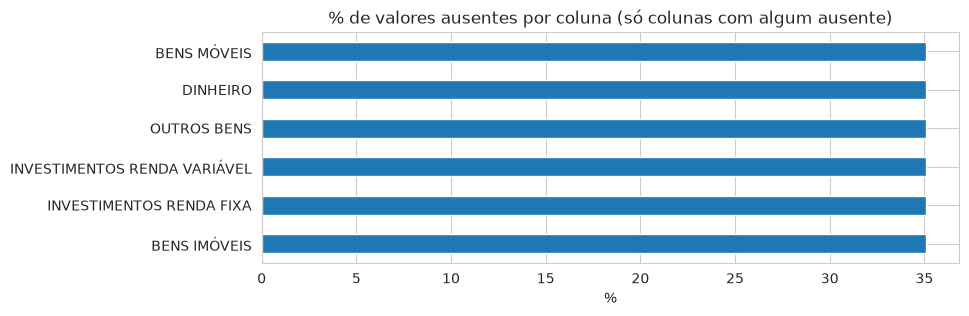

In [13]:
print(f"{df.shape[0]} candidatos x {df.shape[1]} colunas\n")
display(df.dtypes.value_counts().rename('nº de colunas'))

faltantes = (df.isna().mean() * 100).sort_values(ascending=False)
faltantes = faltantes[faltantes > 0]

if len(faltantes) > 0:
    plt.figure(figsize=(9, max(3, len(faltantes) * 0.3)))
    faltantes.plot(kind='barh')
    plt.title('% de valores ausentes por coluna (só colunas com algum ausente)')
    plt.xlabel('%')
    plt.gca().invert_yaxis()
    plt.show()
else:
    print("Nenhuma coluna com valores ausentes.")

## 2) Escolhendo o que explorar

O dataset tem dezenas de colunas — muitas são identificadores administrativos (`SQ_CANDIDATO`, `NR_CPF_CANDIDATO`, `DS_EMAIL`, hashes de geração...) sem valor analítico. As duas listas abaixo reúnem as colunas com conteúdo substantivo — **sintam-se livres para adicionar outras que despertarem curiosidade** (`df.columns` mostra tudo o que está disponível).

In [14]:
display(pd.DataFrame({"Coluna": df.columns}))

,Coluna
0,DT_GERACAO
1,HH_GERACAO
2,ANO_ELEICAO
3,CD_TIPO_ELEICAO
4,NM_TIPO_ELEICAO
5,NR_TURNO
6,CD_ELEICAO
7,DS_ELEICAO
8,DT_ELEICAO
9,TP_ABRANGENCIA


In [15]:
colunas_numericas = [
    'IDADE',
    'Total_Bens',
    'Total_Bens_Log',
    'BENS MÓVEIS',
    'BENS IMÓVEIS',
    'DINHEIRO',
    'INVESTIMENTOS RENDA FIXA',
    'INVESTIMENTOS RENDA VARIÁVEL',
    'OUTROS BENS',
]
colunas_numericas = [c for c in colunas_numericas if c in df.columns]

colunas_categoricas = [
    'DS_GENERO',
    'DS_ESTADO_CIVIL',
    'DS_COR_RACA',
    'DS_GRAU_INSTRUCAO',
    'DS_SITUACAO_CANDIDATURA',
    'DS_SIT_TOT_TURNO',
    'TP_AGREMIACAO',
    'SG_PARTIDO',
    'DS_OCUPACAO',
    'NR_TURNO',
    'SG_UE',
]
colunas_categoricas = [c for c in colunas_categoricas if c in df.columns]

print("Numéricas:")
display(pd.DataFrame({"Coluna": colunas_numericas}))
print("Categóricas:")
display(pd.DataFrame({"Coluna": colunas_categoricas}))

Numéricas:


,Coluna
0,IDADE
1,Total_Bens
2,Total_Bens_Log
3,BENS MÓVEIS
4,BENS IMÓVEIS
5,DINHEIRO
6,INVESTIMENTOS RENDA FIXA
7,INVESTIMENTOS RENDA VARIÁVEL
8,OUTROS BENS


Categóricas:


,Coluna
0,DS_GENERO
1,DS_ESTADO_CIVIL
2,DS_COR_RACA
3,DS_GRAU_INSTRUCAO
4,DS_SITUACAO_CANDIDATURA
5,DS_SIT_TOT_TURNO
6,TP_AGREMIACAO
7,SG_PARTIDO
8,DS_OCUPACAO
9,NR_TURNO


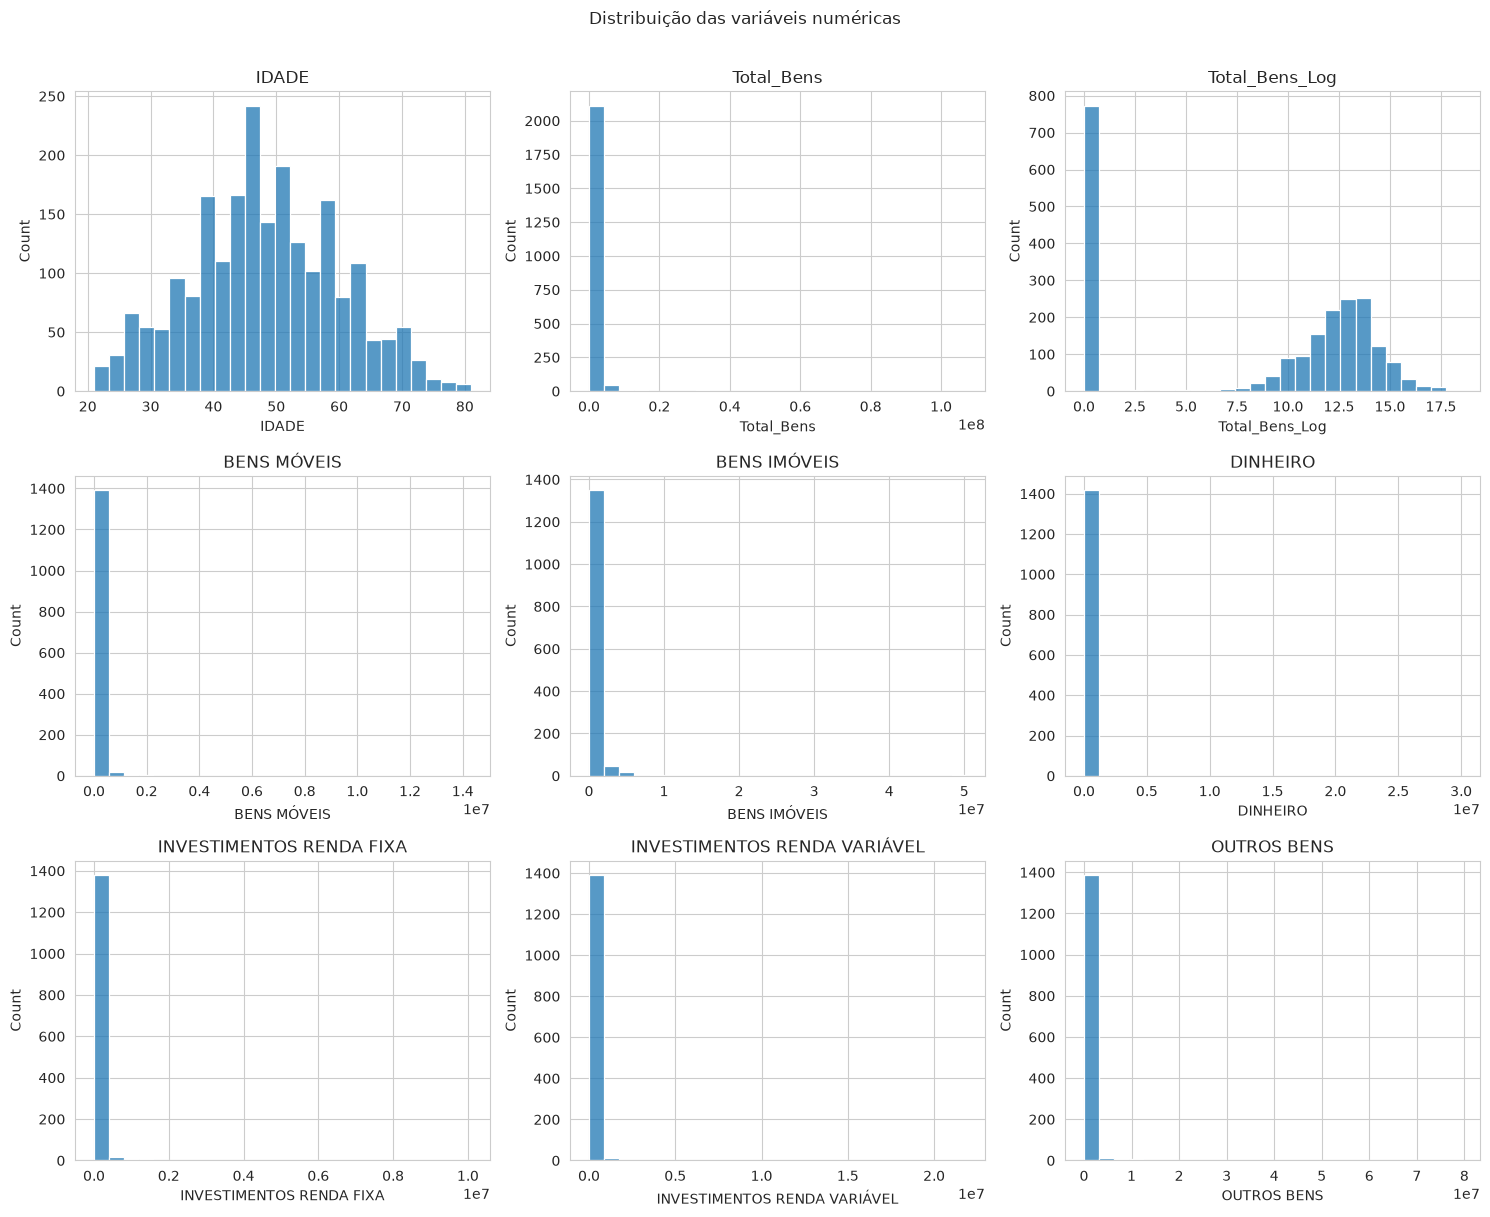

In [16]:
n = len(colunas_numericas)
ncols = 3
nrows = -(-n // ncols)  # arredonda pra cima

fig, axes = plt.subplots(nrows, ncols, figsize=(15, 4 * nrows))
axes = axes.flatten()

for i, col in enumerate(colunas_numericas):
    sns.histplot(df[col], bins=25, ax=axes[i])
    axes[i].set_title(col)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('Distribuição das variáveis numéricas', y=1.01)
plt.tight_layout()
plt.show()

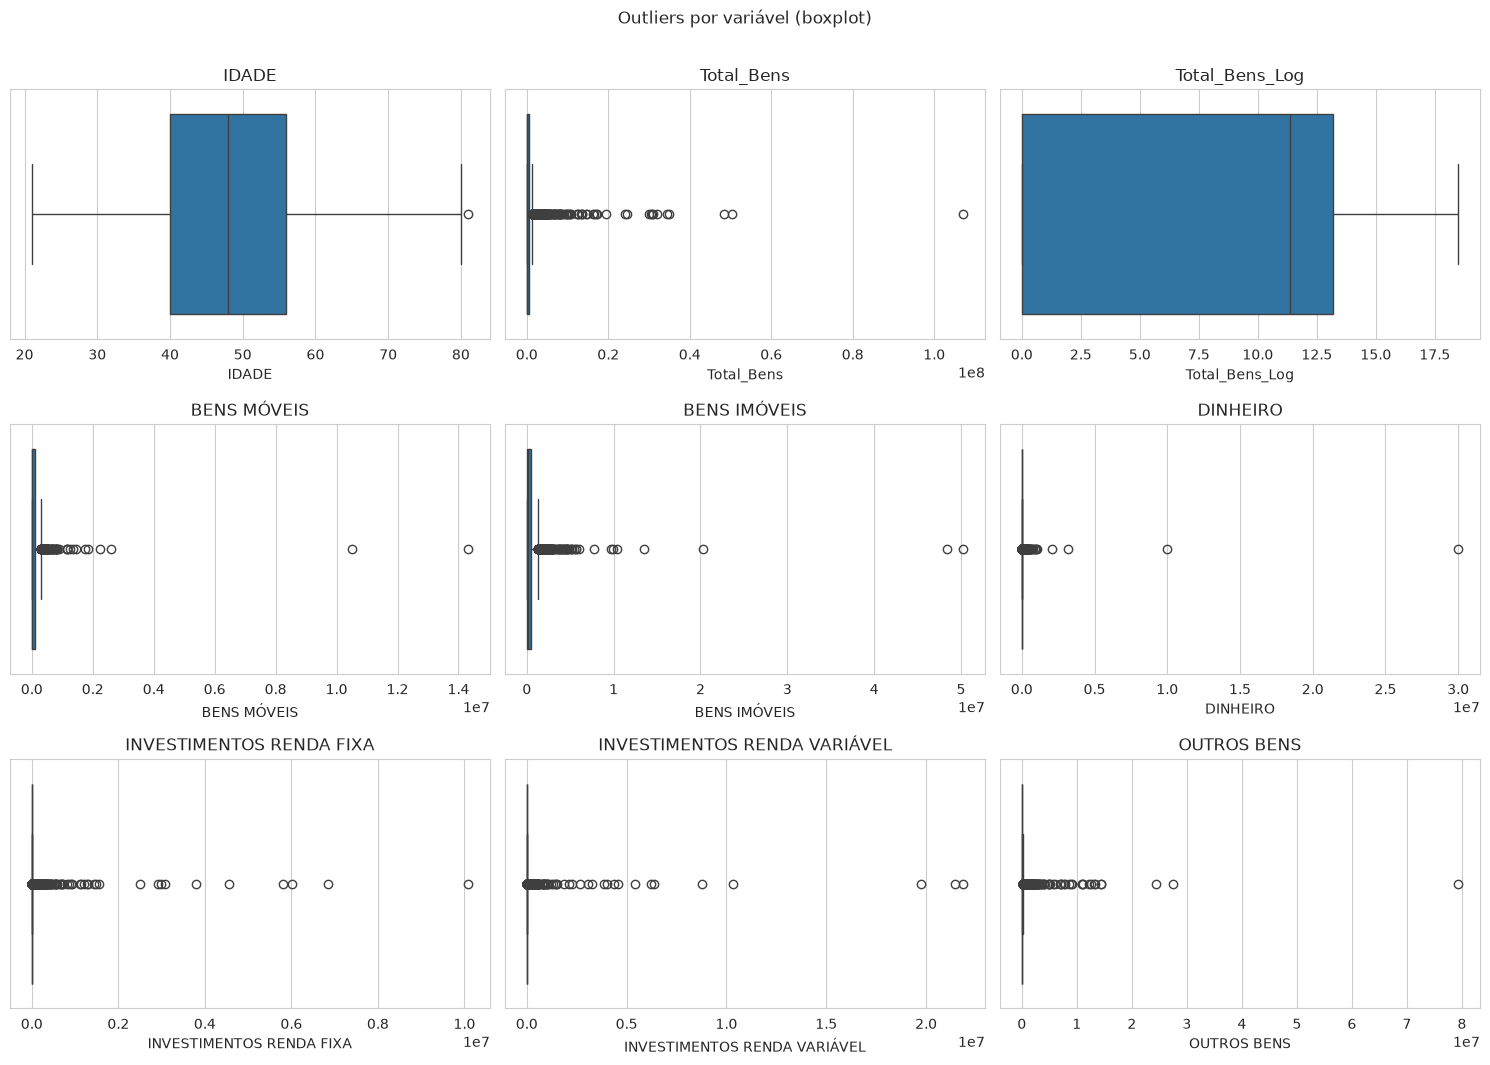

In [17]:
fig, axes = plt.subplots(nrows, ncols, figsize=(15, 3.5 * nrows))
axes = axes.flatten()

for i, col in enumerate(colunas_numericas):
    sns.boxplot(x=df[col], ax=axes[i])
    axes[i].set_title(col)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('Outliers por variável (boxplot)', y=1.01)
plt.tight_layout()
plt.show()

### 3.1) Quantificando os outliers (regra do IQR)

O boxplot mostra visualmente; esta tabela quantifica: quantos candidatos ficam fora do intervalo `[Q1 - 1.5·IQR, Q3 + 1.5·IQR]` em cada variável.

In [18]:
linhas = []
for col in colunas_numericas:
    Q1, Q3 = df[col].quantile([0.25, 0.75])
    IQR = Q3 - Q1
    lim_inf, lim_sup = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    n_outliers = ((df[col] < lim_inf) | (df[col] > lim_sup)).sum()
    linhas.append({
        'variavel': col, 'limite_inferior': lim_inf, 'limite_superior': lim_sup,
        'qtd_outliers': n_outliers, 'pct_outliers': round(100 * n_outliers / len(df), 1),
    })

pd.DataFrame(linhas).sort_values('pct_outliers', ascending=False)

,variavel,limite_inferior,limite_superior,qtd_outliers,pct_outliers
5,DINHEIRO,"-1,313.76","2,189.60",330,15.10
6,INVESTIMENTOS RENDA FIXA,0.00,0.00,322,14.70
7,INVESTIMENTOS RENDA VARIÁVEL,0.00,0.00,272,12.40
8,OUTROS BENS,"-88,500.00","147,500.00",267,12.20
1,Total_Bens,"-810,000.00","1,350,000.00",241,11.00
4,BENS IMÓVEIS,"-750,000.00","1,250,000.00",132,6.00
3,BENS MÓVEIS,"-178,500.00","297,500.00",123,5.60
0,IDADE,16.00,80.00,1,0.00
2,Total_Bens_Log,-19.80,33.00,0,0.00


## 4) Variáveis categóricas: contagens e proporções

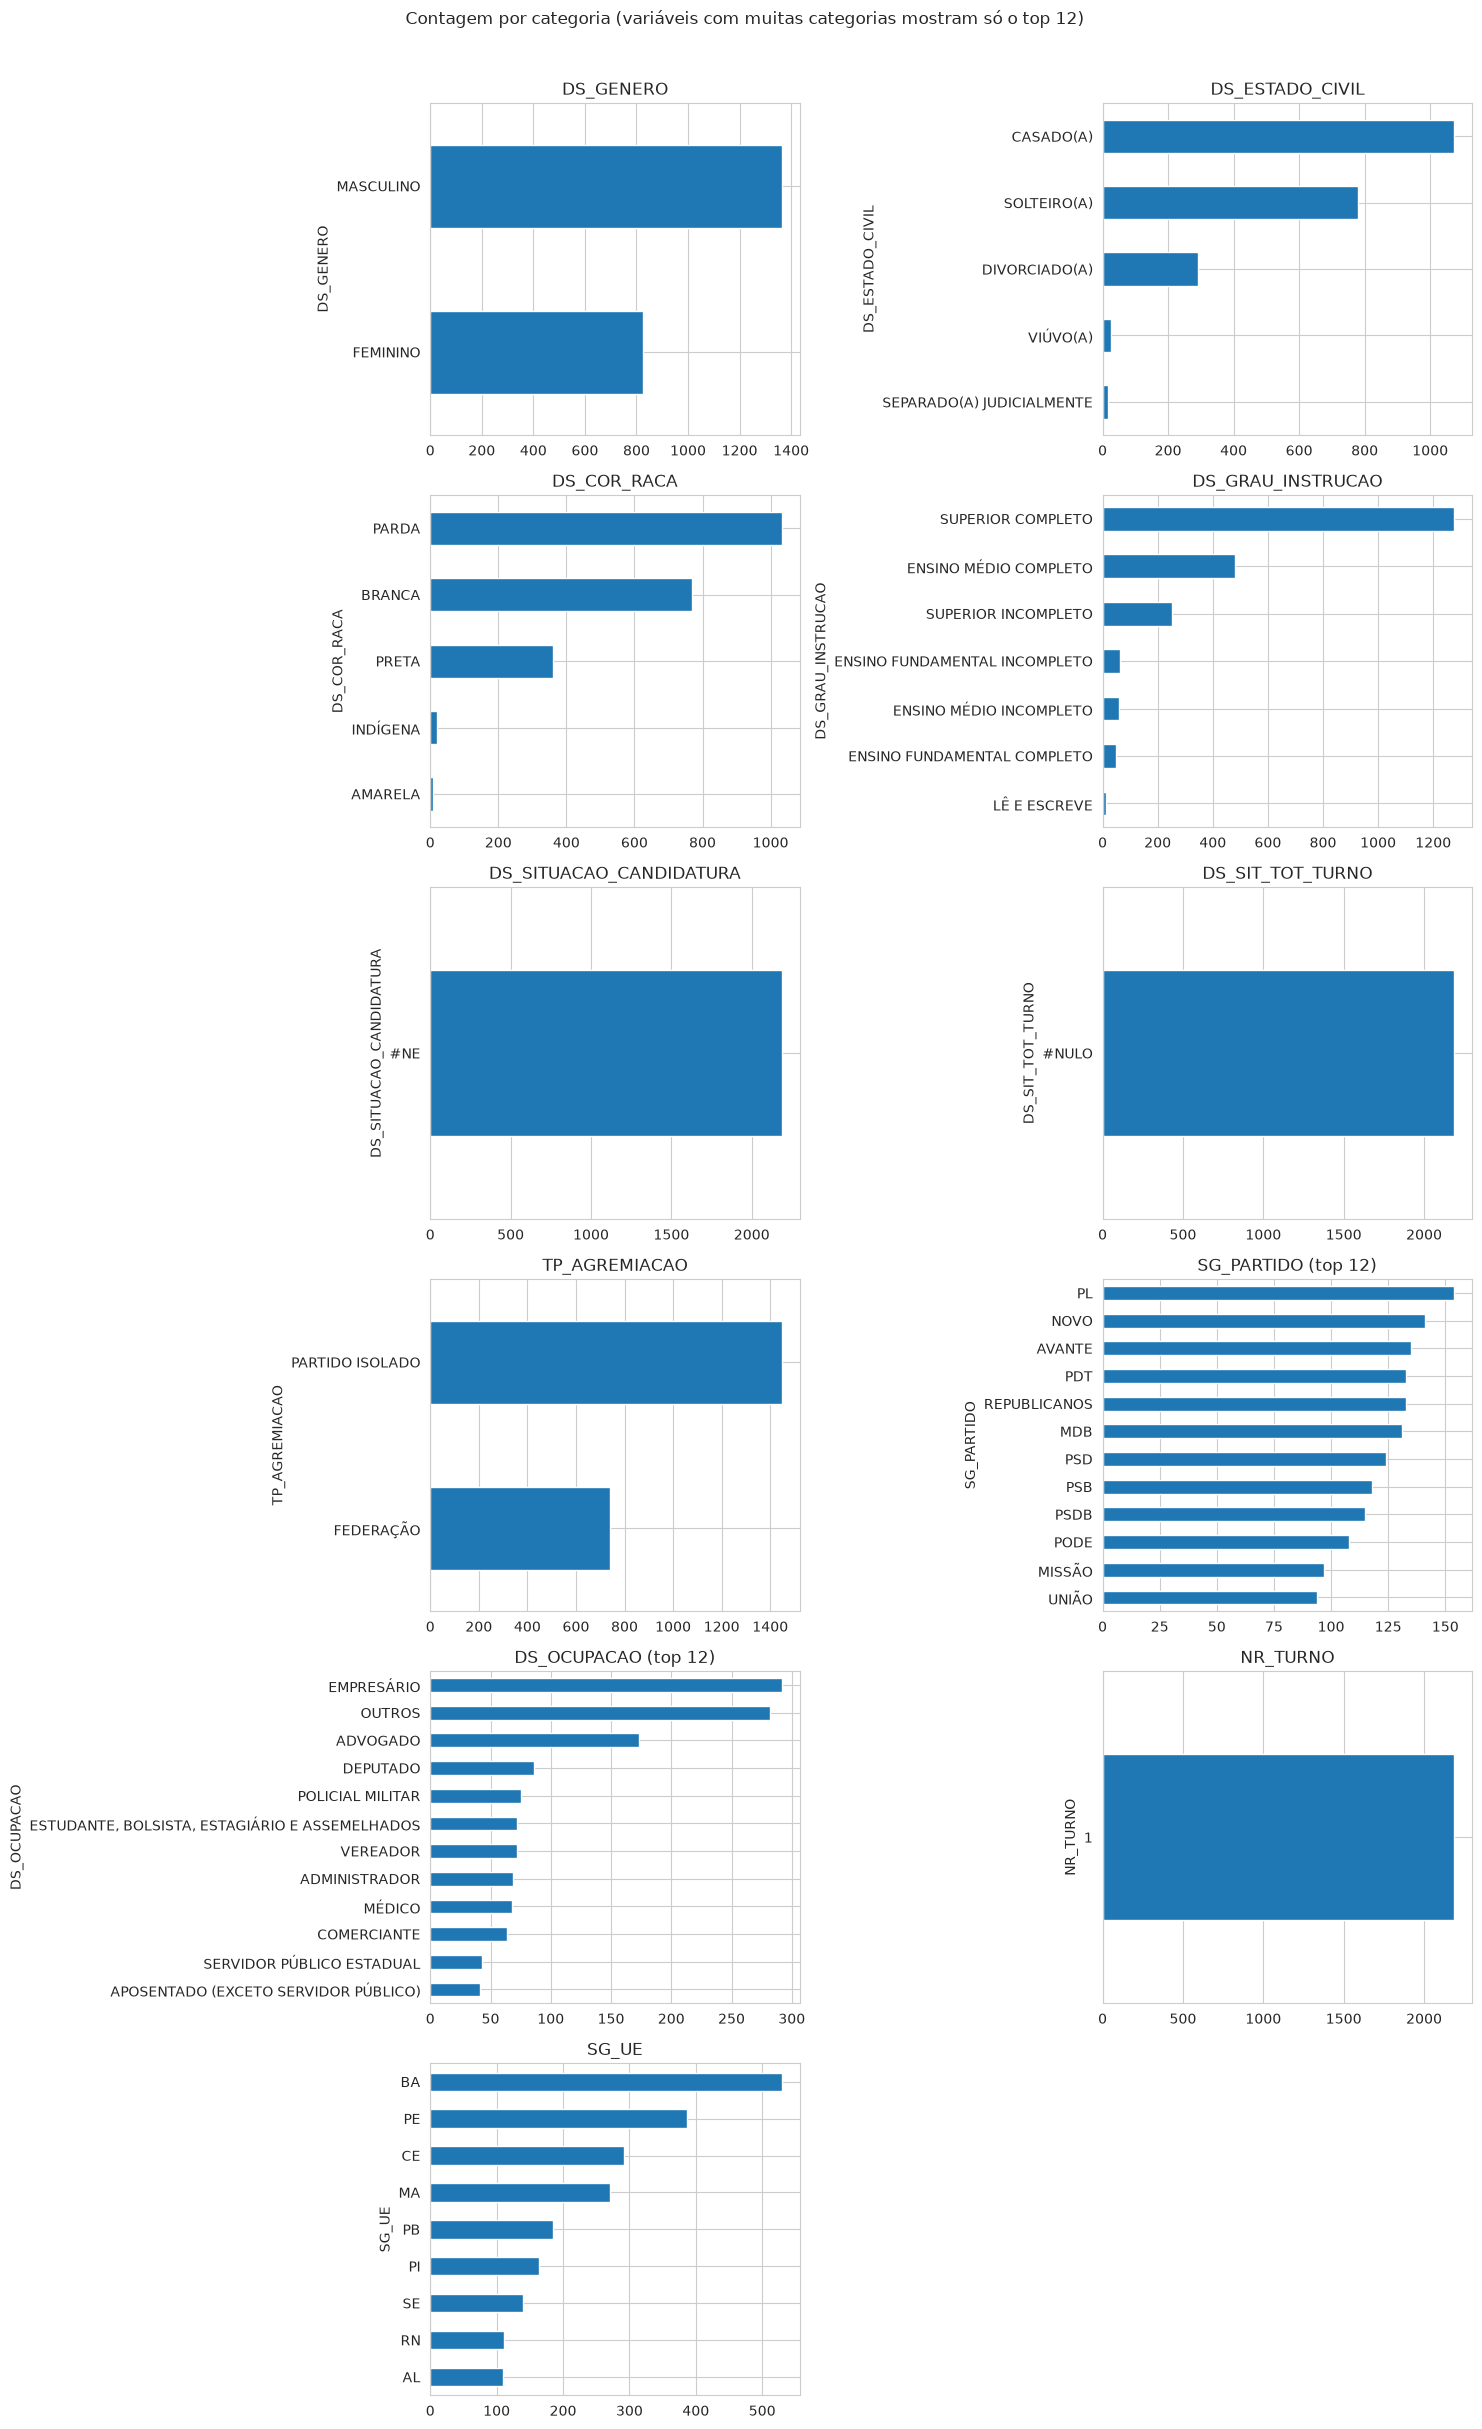

In [19]:
def plot_categorica(ax, coluna, top_n=12):
    contagem = df[coluna].value_counts().head(top_n)
    contagem.plot(kind='barh', ax=ax)
    ax.set_title(coluna + (f' (top {top_n})' if df[coluna].nunique() > top_n else ''))
    ax.invert_yaxis()

n = len(colunas_categoricas)
ncols = 2
nrows = -(-n // ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(15, 4 * nrows))
axes = axes.flatten()

for i, col in enumerate(colunas_categoricas):
    plot_categorica(axes[i], col)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('Contagem por categoria (variáveis com muitas categorias mostram só o top 12)', y=1.01)
plt.tight_layout()
plt.show()

In [20]:
for col in colunas_categoricas:
    print(f"--- {col} ({df[col].nunique()} categorias) ---")
    print((df[col].value_counts(normalize=True).head(8) * 100).round(1).astype(str) + '%')
    print()

--- DS_GENERO (2 categorias) ---
DS_GENERO
MASCULINO    62.4%
FEMININO     37.6%
Name: proportion, dtype: str

--- DS_ESTADO_CIVIL (5 categorias) ---
DS_ESTADO_CIVIL
CASADO(A)                    49.1%
SOLTEIRO(A)                  35.7%
DIVORCIADO(A)                13.3%
VIÚVO(A)                      1.1%
SEPARADO(A) JUDICIALMENTE     0.8%
Name: proportion, dtype: str

--- DS_COR_RACA (5 categorias) ---
DS_COR_RACA
PARDA       47.2%
BRANCA      35.1%
PRETA       16.4%
INDÍGENA     0.9%
AMARELA      0.4%
Name: proportion, dtype: str

--- DS_GRAU_INSTRUCAO (7 categorias) ---
DS_GRAU_INSTRUCAO
SUPERIOR COMPLETO                58.3%
ENSINO MÉDIO COMPLETO            21.9%
SUPERIOR INCOMPLETO              11.6%
ENSINO FUNDAMENTAL INCOMPLETO     2.9%
ENSINO MÉDIO INCOMPLETO           2.7%
ENSINO FUNDAMENTAL COMPLETO       2.1%
LÊ E ESCREVE                      0.5%
Name: proportion, dtype: str

--- DS_SITUACAO_CANDIDATURA (1 categorias) ---
DS_SITUACAO_CANDIDATURA
#NE    100.0%
Name: proportio

## 5) Dispersão entre variáveis numéricas

Correlação e gráficos de dispersão par a par — sem nenhuma variável de destaque, só pra ver como as variáveis se relacionam (ou não).

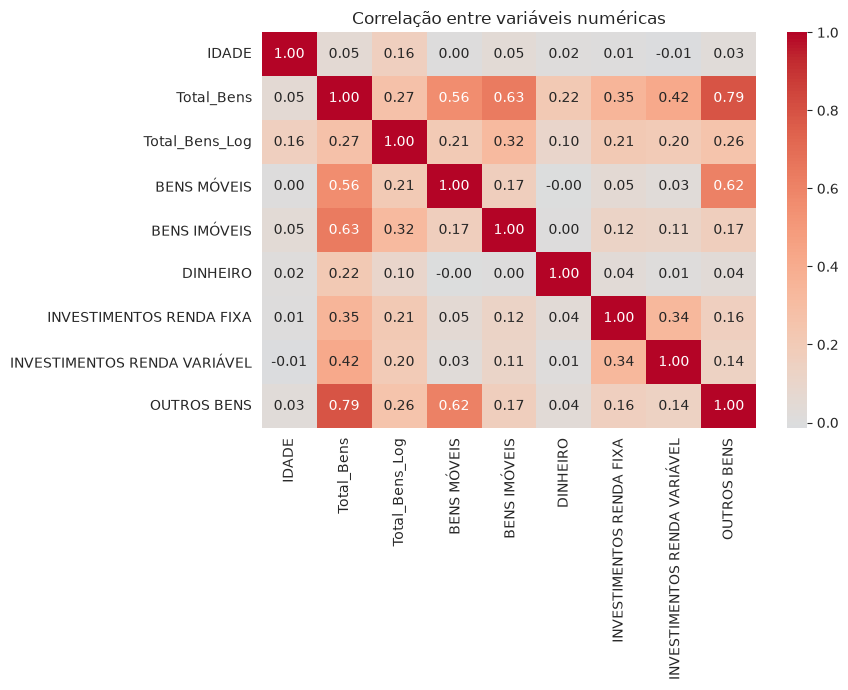

In [21]:
plt.figure(figsize=(9, 7))
sns.heatmap(df[colunas_numericas].corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlação entre variáveis numéricas')
plt.tight_layout()
plt.show()

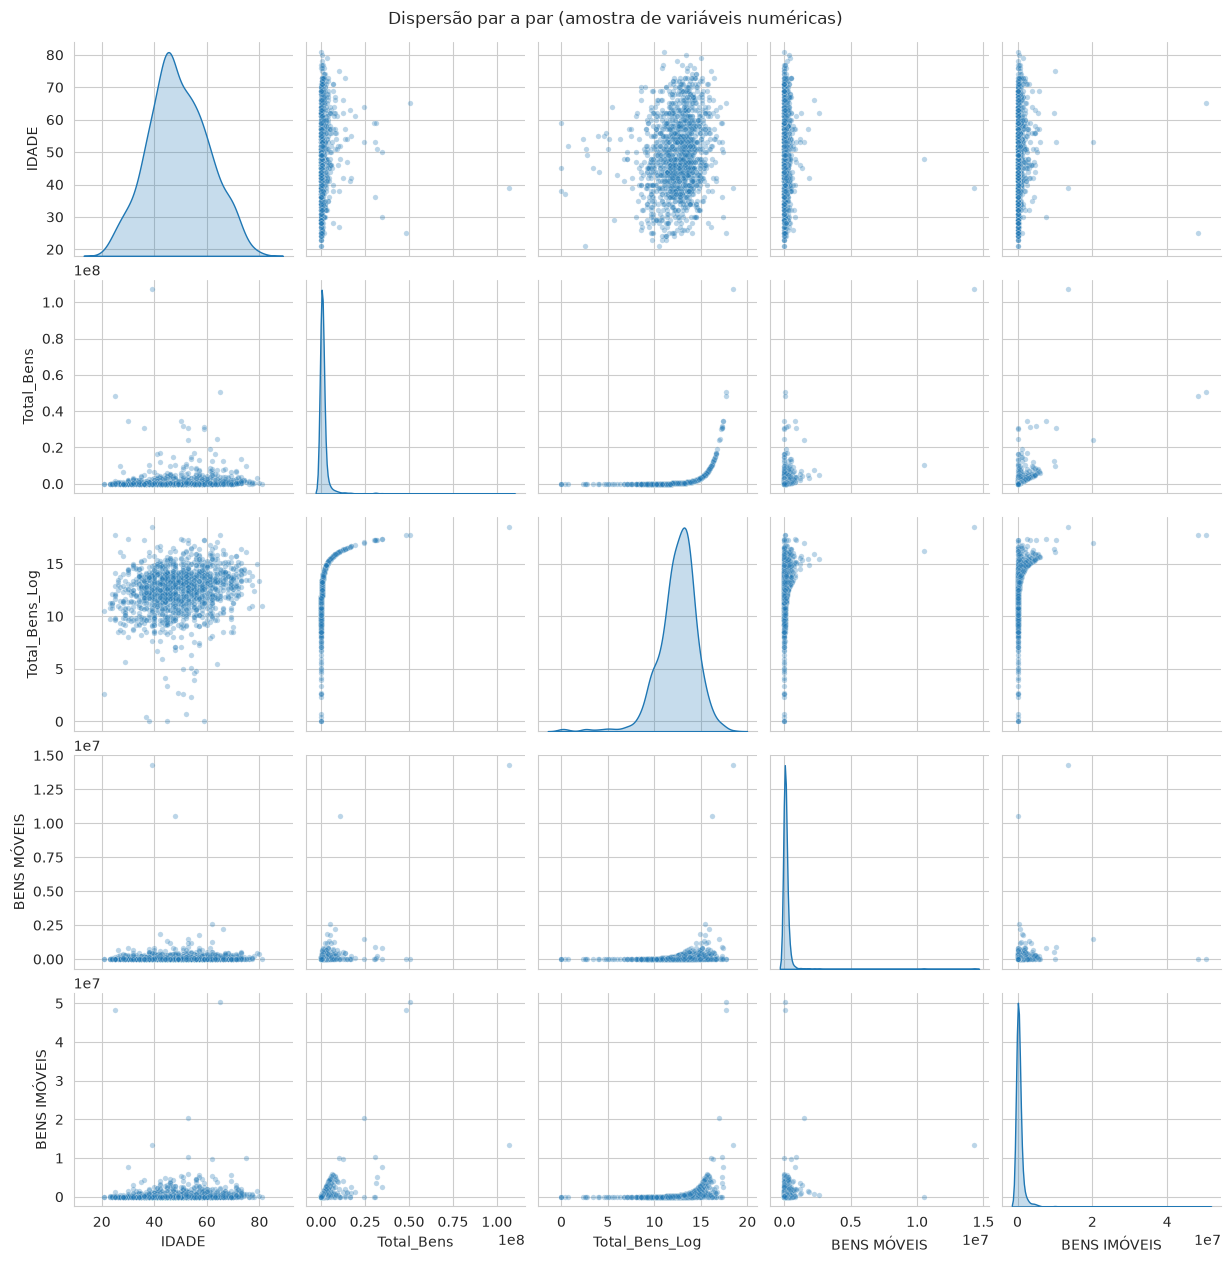

In [22]:
# Pairplot com um subconjunto (pairplot com muitas variáveis fica pesado/ilegível)
subset = colunas_numericas[:5]
sns.pairplot(df[subset].dropna(), diag_kind='kde', plot_kws={'alpha': 0.3, 's': 15})
plt.suptitle('Dispersão par a par (amostra de variáveis numéricas)', y=1.01)
plt.show()

### 5.1) Um exemplo de dispersão colorida

Só um exemplo de como cruzar uma variável numérica com outra numérica *e* uma categórica ao mesmo tempo — troquem `x`, `y` e `hue` livremente para explorar outras combinações.

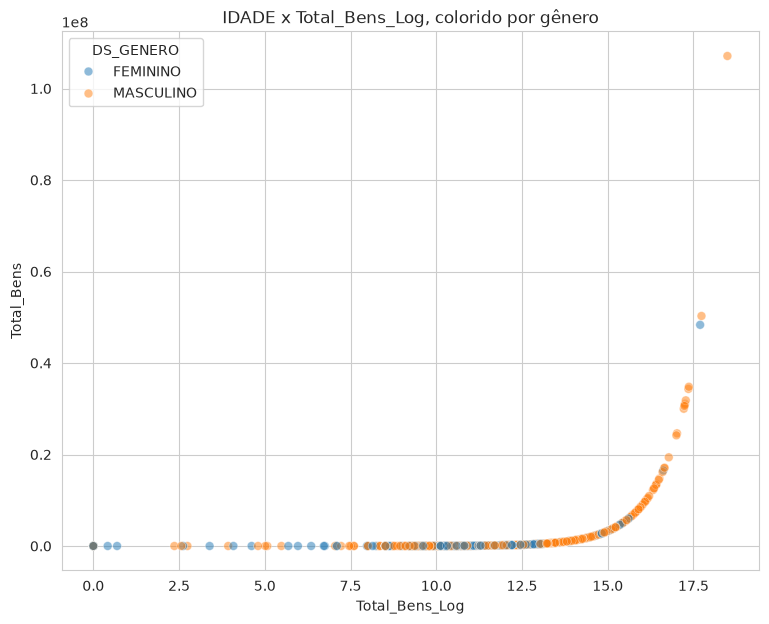

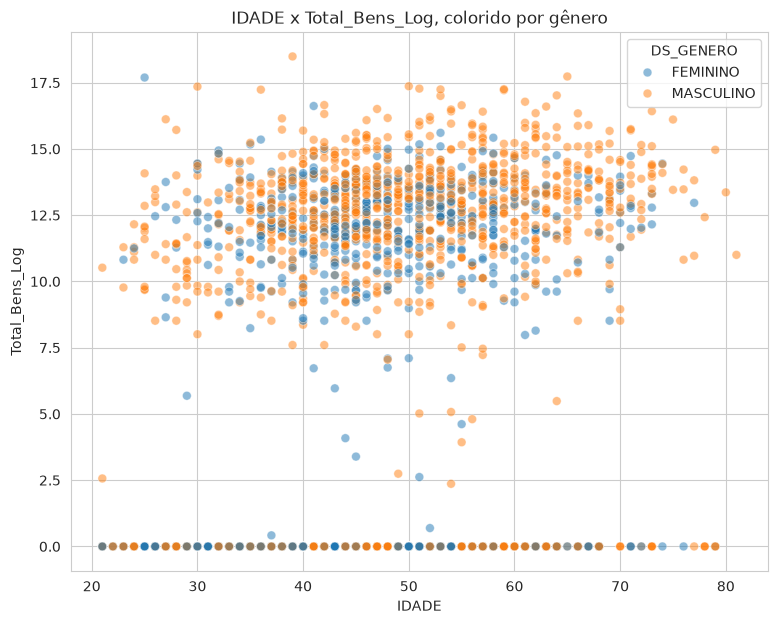

In [31]:
plt.figure(figsize=(9, 7))
sns.scatterplot(data=df, x='Total_Bens_Log', y='Total_Bens', hue='DS_GENERO', alpha=0.5, s=40)
plt.title('IDADE x Total_Bens_Log, colorido por gênero')
plt.show()

plt.figure(figsize=(9, 7))
sns.scatterplot(data=df, x='IDADE', y='Total_Bens_Log', hue='DS_GENERO', alpha=0.5, s=40)
plt.title('IDADE x Total_Bens_Log, colorido por gênero')
plt.show()

## 6) Proporções entre grupos

Alguns exemplos de cruzamentos categóricos — não são os únicos possíveis, só uma amostra do tipo de pergunta que dá pra fazer.

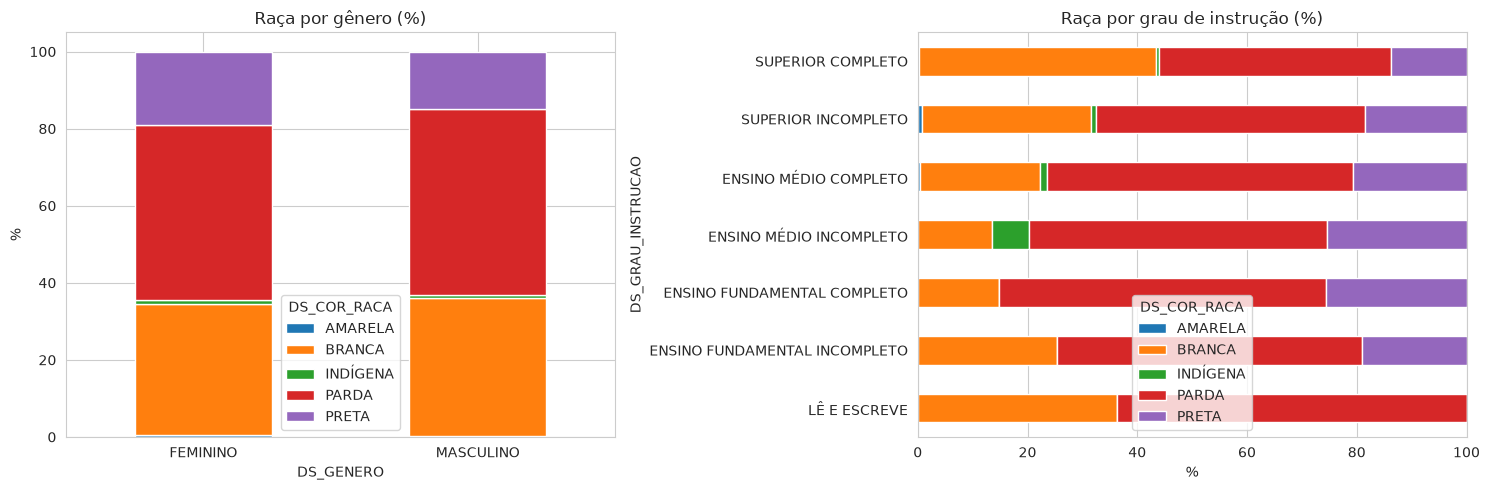

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

pd.crosstab(df['DS_GENERO'], df['DS_COR_RACA'], normalize='index').mul(100).plot(
    kind='bar', stacked=True, ax=axes[0]
)
axes[0].set_title('Raça por gênero (%)')
axes[0].set_ylabel('%')
axes[0].tick_params(axis='x', rotation=0)

ordem_instrucao = df[['CD_GRAU_INSTRUCAO', 'DS_GRAU_INSTRUCAO']].drop_duplicates().sort_values('CD_GRAU_INSTRUCAO')['DS_GRAU_INSTRUCAO']
pd.crosstab(df['DS_GRAU_INSTRUCAO'], df['DS_COR_RACA'], normalize='index').loc[ordem_instrucao].mul(100).plot(
    kind='barh', stacked=True, ax=axes[1]
)
axes[1].set_title('Raça por grau de instrução (%)')
axes[1].set_xlabel('%')

plt.tight_layout()
plt.show()

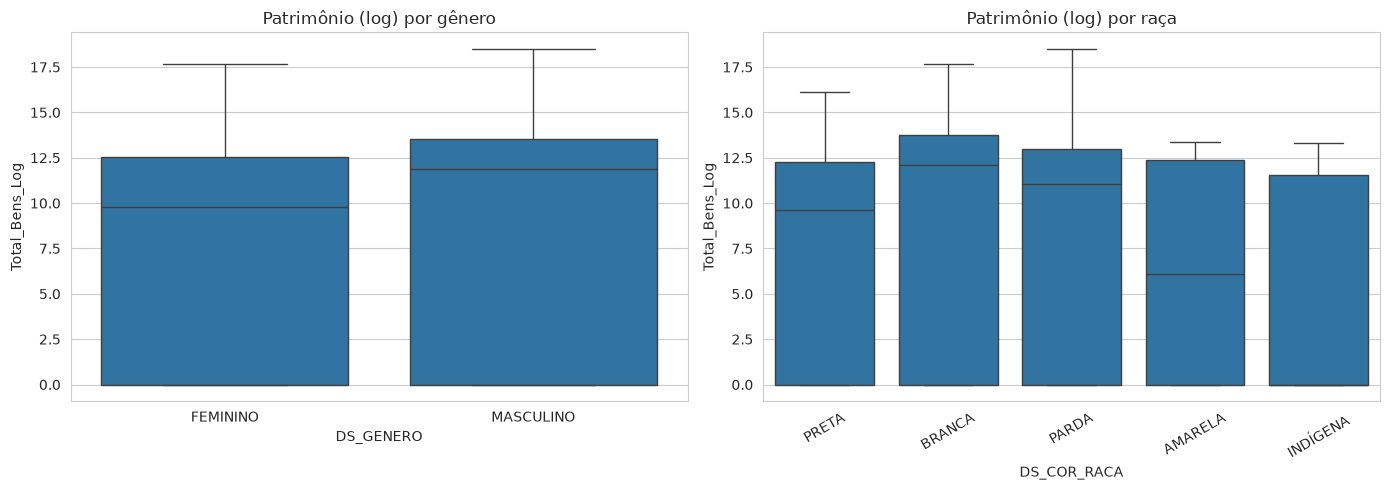

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=df, x='DS_GENERO', y='Total_Bens_Log', ax=axes[0])
axes[0].set_title('Patrimônio (log) por gênero')

sns.boxplot(data=df, x='DS_COR_RACA', y='Total_Bens_Log', ax=axes[1])
axes[1].set_title('Patrimônio (log) por raça')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

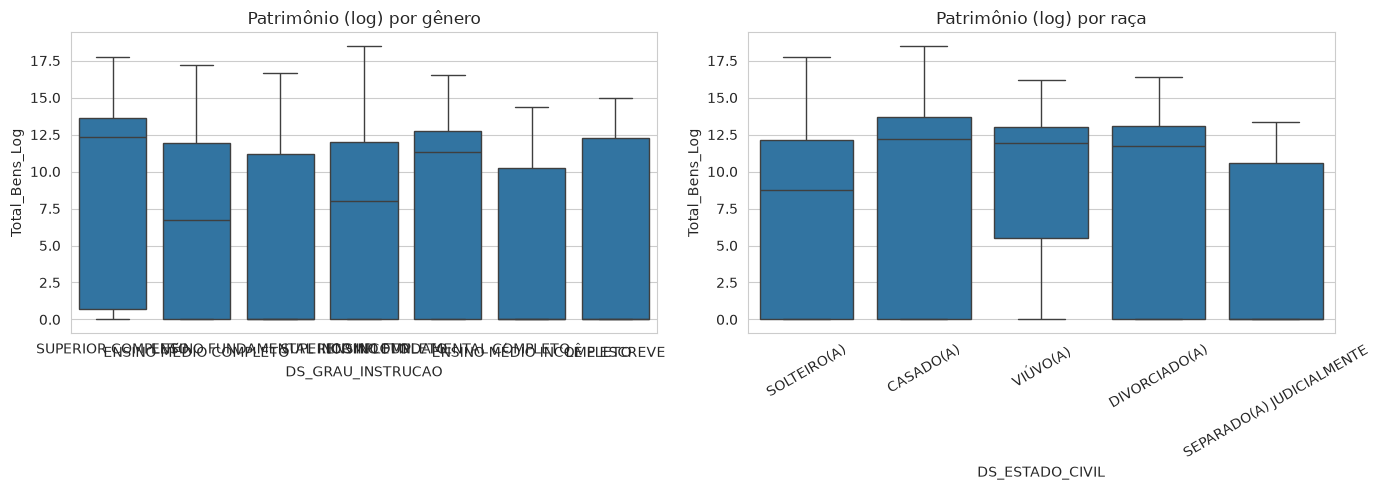

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=df, x='DS_GRAU_INSTRUCAO', y='Total_Bens_Log', ax=axes[0])
axes[0].set_title('Patrimônio (log) por gênero')

sns.boxplot(data=df, x='DS_ESTADO_CIVIL', y='Total_Bens_Log', ax=axes[1])
axes[1].set_title('Patrimônio (log) por raça')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

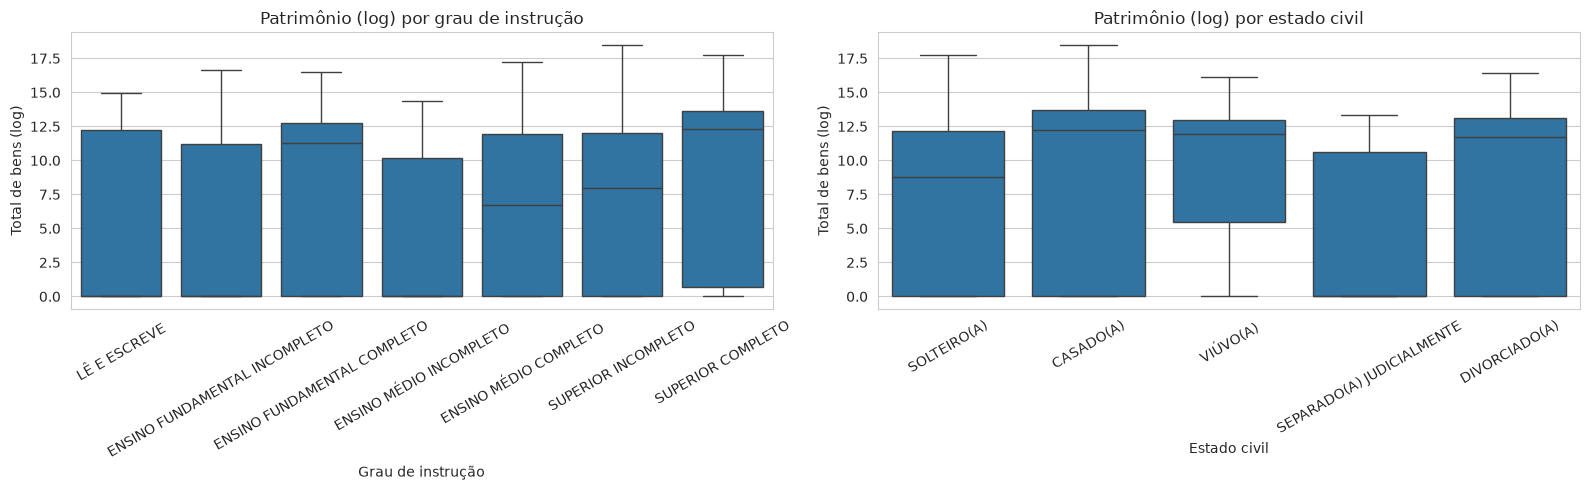

In [35]:
# Ordem do grau de instrução pelo respectivo código
ordem_instrucao = (
    df[['CD_GRAU_INSTRUCAO', 'DS_GRAU_INSTRUCAO']]
    .drop_duplicates()
    .sort_values('CD_GRAU_INSTRUCAO')
    ['DS_GRAU_INSTRUCAO']
    .tolist()
)

# Ordem do estado civil pelo respectivo código
ordem_estado_civil = (
    df[['CD_ESTADO_CIVIL', 'DS_ESTADO_CIVIL']]
    .drop_duplicates()
    .sort_values('CD_ESTADO_CIVIL')
    ['DS_ESTADO_CIVIL']
    .tolist()
)


# Cria os dois gráficos lado a lado
fig, axes = plt.subplots(1, 2, figsize=(16, 5))


# Grau de instrução
sns.boxplot(
    data=df,
    x='DS_GRAU_INSTRUCAO',
    y='Total_Bens_Log',
    order=ordem_instrucao,
    ax=axes[0]
)

axes[0].set_title('Patrimônio (log) por grau de instrução')
axes[0].set_xlabel('Grau de instrução')
axes[0].set_ylabel('Total de bens (log)')
axes[0].tick_params(axis='x', rotation=30)


# Estado civil
sns.boxplot(
    data=df,
    x='DS_ESTADO_CIVIL',
    y='Total_Bens_Log',
    order=ordem_estado_civil,
    ax=axes[1]
)

axes[1].set_title('Patrimônio (log) por estado civil')
axes[1].set_xlabel('Estado civil')
axes[1].set_ylabel('Total de bens (log)')
axes[1].tick_params(axis='x', rotation=30)


plt.tight_layout()
plt.show()

## 7) Comparação entre UFs

Comparação entre os 9 estados do Nordeste

7.1 Candidatos por UF

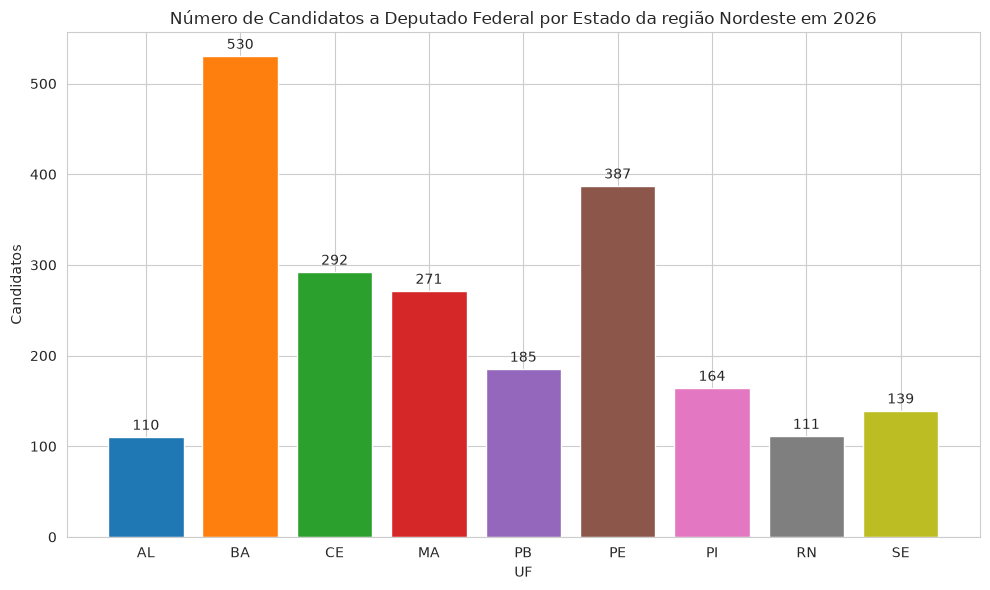

       Candidatos  % do total
SG_UF                        
AL            110        5.00
BA            530       24.20
CE            292       13.30
MA            271       12.40
PB            185        8.50
PE            387       17.70
PI            164        7.50
RN            111        5.10
SE            139        6.30


In [36]:
cand_por_uf = df['SG_UF'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(10,6))
bars = ax.bar(cand_por_uf.index, cand_por_uf.values,
              color=sns.color_palette('tab10', len(cand_por_uf)))
ax.bar_label(bars, padding=3)
ax.set_title('Número de Candidatos a Deputado Federal por Estado da região Nordeste em 2026')
ax.set_xlabel('UF')
ax.set_ylabel('Candidatos')
plt.tight_layout()
plt.show()

print(pd.DataFrame({'Candidatos': cand_por_uf, '% do total':
                    (cand_por_uf / len(df) * 100).round(1)}))

Observações: É possível notar uma maior concentração de candidatos na Bahia, quase 25% do total de candidatos do Nordeste.

7.2 Patrimônio por UF (Mediana e média)

In [37]:
pat_mediana = df.groupby('SG_UF')['Total_Bens'].median().sort_values()
pat_media = df.groupby('SG_UF')['Total_Bens'].mean().reindex(pat_mediana.index)
print(pat_mediana)
print(pat_media)

SG_UF
PI    17,039.08
RN    18,000.00
PB    23,000.00
PE    72,887.43
AL    78,500.00
BA    80,000.00
SE    92,000.00
CE   101,000.00
MA   250,000.00
Name: Total_Bens, dtype: float64
SG_UF
PI   1,111,525.70
RN     339,233.52
PB     549,882.54
PE     854,766.35
AL   1,072,330.27
BA     893,530.38
SE     591,658.28
CE     779,260.49
MA   1,004,082.47
Name: Total_Bens, dtype: float64


Observação: É possível notar uma forte assimetria indicando outliers, algo que vimos em 1.1, para resolvermos isso vamos remover os candidatos que não declararam seus bens (menor ou igual a zero) ou que não possuem bens.

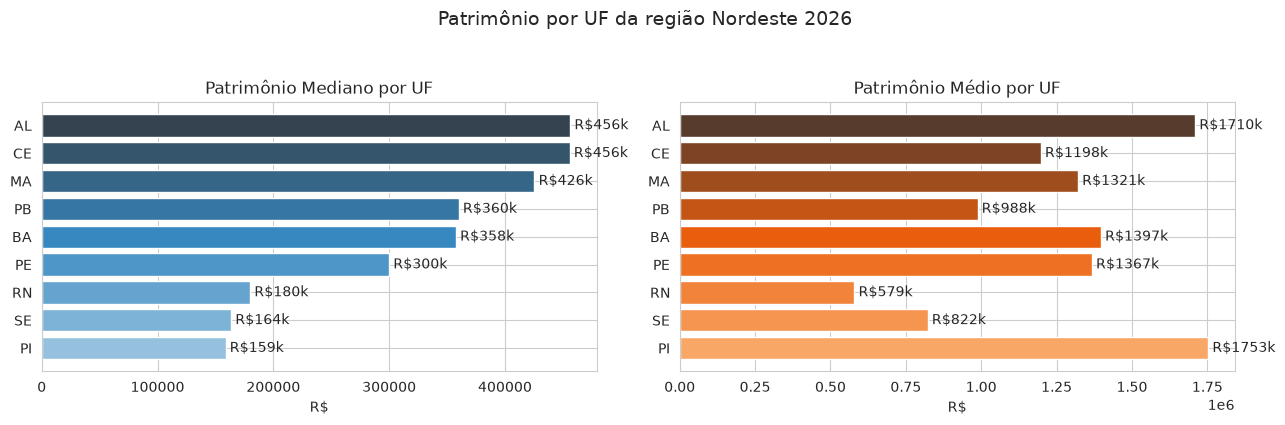

In [38]:
df_pat_sem_zeros = df[df['Total_Bens'] > 0]
pat_mediana = df_pat_sem_zeros.groupby('SG_UF')['Total_Bens'].median().sort_values()
pat_media = df_pat_sem_zeros.groupby('SG_UF')['Total_Bens'].mean().reindex(pat_mediana.index)

fig, axes = plt.subplots(1, 2, figsize=(13,4))

fig.suptitle('Patrimônio por UF da região Nordeste 2026', fontsize=14, y=1.05)

bars = axes[0].barh(pat_mediana.index, pat_mediana.values,
                    color=sns.color_palette('Blues_d', len(pat_mediana)))
axes[0].bar_label(bars, labels=[f'R${v/1e3:.0f}k' for v in pat_mediana.values], padding=3)
axes[0].set_title('Patrimônio Mediano por UF')
axes[0].set_xlabel('R$')

bars2 = axes[1].barh(pat_media.index, pat_media.values,
                     color=sns.color_palette('Oranges_d', len(pat_media)))
axes[1].bar_label(bars2, labels=[f'R${v/1e3:.0f}k' for v in pat_media.values], padding=3)
axes[1].set_title('Patrimônio Médio por UF')
axes[1].set_xlabel('R$')

plt.tight_layout()
plt.show()

Observação: Nota-se pelos gráficos que a política regional não é feita por candidatos com perfis financeiros homogêneos, mas sim por uma base enorme de pessoas comuns acompanhada de uma elite financeira minúscula que distorce todo o montante de riqueza declarado. Isso se torna mais visível no exemplo do Piauí (PI), onde a mediana é de R$ 159 mil em patrimônio, enquanto a média salta para R$ 1,75 milhão. Ou seja, um pequeno grupo de candidatos extremamente ricos distorce completamente a média da análise — formando justamente a 'cauda longa' que precisou ser comprimida pela escala logarítmica no histograma do ponto 1.1 para permitir a visualização da distribuição.

7.2.1 Distribuição de Patrimônio por UF (log10)

Para visualizarmos melhor esses outliers vamos visualizar o boxplot dos patrimônios por UF com log de base 10.

Obs: Vamos novamente remover os valores menores que 0.

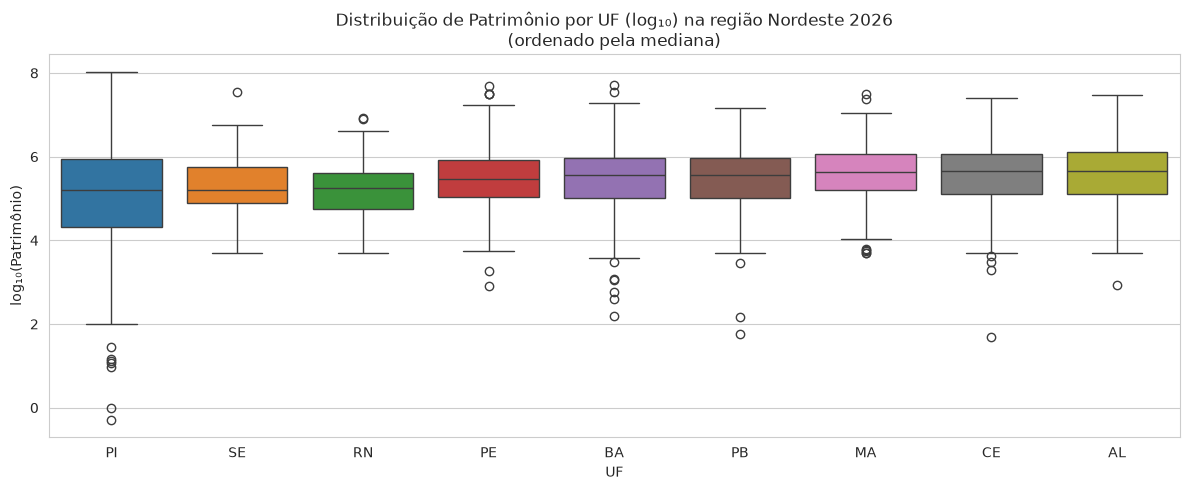

In [39]:
df_plot_uf = df[df['Total_Bens'] > 0].copy()
df_plot_uf['LOG_PAT'] = np.log10(df_plot_uf['Total_Bens'])

ordem_uf = df_plot_uf.groupby('SG_UF')['Total_Bens'].median().sort_values().index

fig, ax = plt.subplots(figsize=(12, 5))
sns.boxplot(data=df_plot_uf, x='SG_UF', y='LOG_PAT', order=ordem_uf,
            palette='tab10', ax=ax)
ax.set_title('Distribuição de Patrimônio por UF (log₁₀) na região Nordeste 2026\n(ordenado pela mediana)')
ax.set_xlabel('UF')
ax.set_ylabel('log₁₀(Patrimônio)')
plt.tight_layout()
plt.show()

Observação: Como podemos ver, o Piauí possui uma grande desigualdade. O boxplot evidencia que o estado tem a maior dispersão (tamanho da caixa) entre todos, mostrando que a riqueza varia drasticamente até mesmo entre os 50% dos candidatos intermediários. A desigualdade é tão estrutural no estado que a caixa alongada empurra o limite da haste superior para valores altíssimos, 'escondendo' os super-ricos dentro do padrão estatístico em escala logarítmica. Além disso, curiosamente, os únicos outliers do estado aparecem na parte inferior, representando candidatos com patrimônios declarados excepcionalmente baixos em relação à média local.

7.3 Idade média por UF

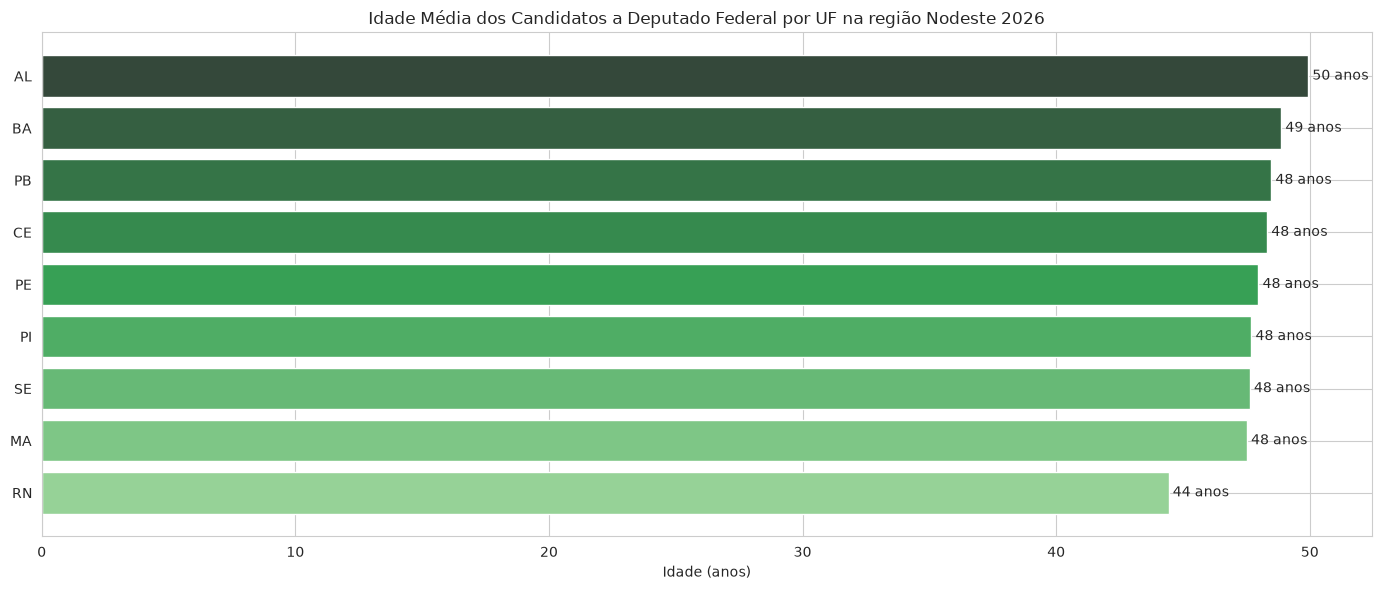

In [40]:
idade_media = df.groupby('SG_UF')['IDADE'].mean().sort_values()

fig, ax = plt.subplots(figsize=(14,6))

bars = ax.barh(idade_media.index, idade_media.values,
               color=sns.color_palette('Greens_d', len(idade_media)))
ax.bar_label(bars, labels=[f'{v:.0f} anos' for v in idade_media], padding=3)
ax.set_title('Idade Média dos Candidatos a Deputado Federal por UF na região Nodeste 2026')
ax.set_xlabel('Idade (anos)')
plt.tight_layout()
plt.show()

Observação: Aqui podemos notar a simetria por idade que vimos também na região nordeste no geral.

7.4 Proporção de Candidatas Mulheres por UF

Para essa analise vamos visualizar a norma presente na Lei das Eleições (Lei nº 9.504/1997), onde exige que partidos assegurem o mínimo de 30% e o máximo de 70% de candidaturas de cada sexo.

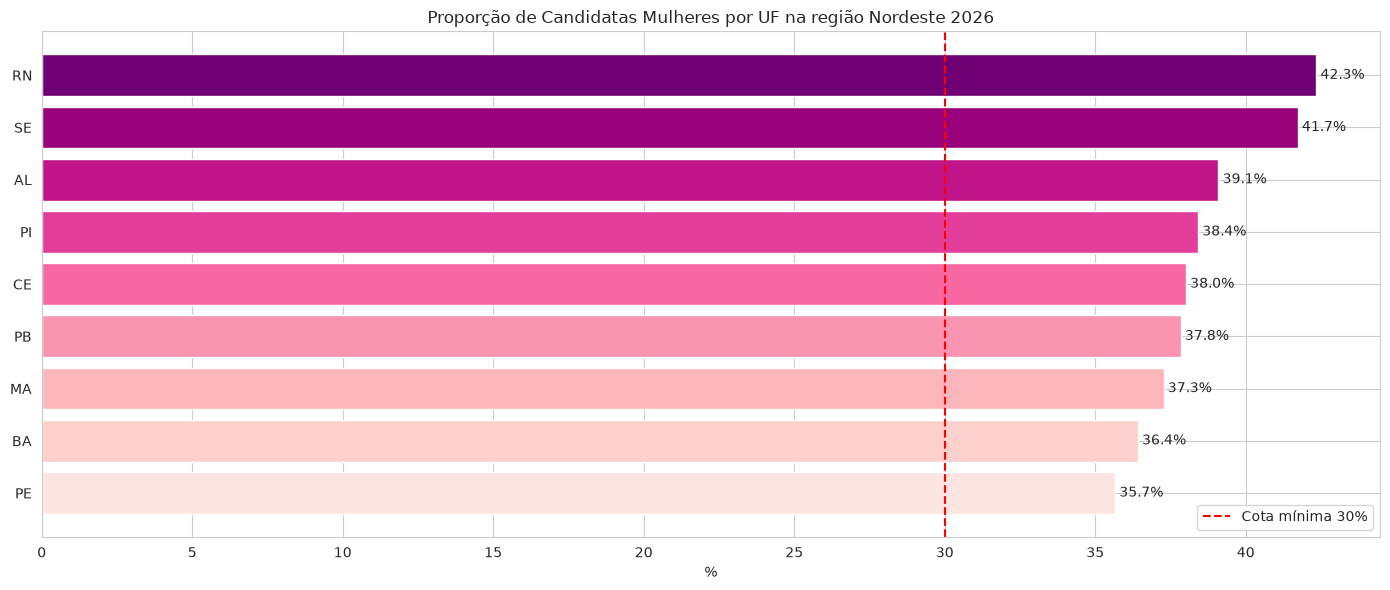

SG_UF
PE   35.70
BA   36.40
MA   37.30
PB   37.80
CE   38.00
PI   38.40
AL   39.10
SE   41.70
RN   42.30
Name: pct_mulheres, dtype: float64


In [41]:
prop_mulheres = (
    df[df['DS_GENERO'].notna()]
    .groupby('SG_UF')
    .apply(lambda x: (x['DS_GENERO'] == 'FEMININO').mean() * 100, include_groups=False)
    .rename('pct_mulheres')
    .sort_values()
)

fig, ax = plt.subplots(figsize=(14, 6))
bars = ax.barh(prop_mulheres.index, prop_mulheres.values,
               color=sns.color_palette('RdPu', len(prop_mulheres)))
ax.bar_label(bars, labels=[f'{v:.1f}%' for v in prop_mulheres.values], padding=3)
ax.axvline(30, color='red', linestyle='--', label='Cota mínima 30%')
ax.set_title('Proporção de Candidatas Mulheres por UF na região Nordeste 2026')
ax.set_xlabel('%')
ax.legend()
plt.tight_layout()
plt.show()

print(prop_mulheres.round(1))

Observação: Como podemos notar, todos os estados respeitaram a cota minima de candidatas e foram além, onde o Rio Grande do Norte quase atinge 50% de candidatas, um excelente indicador de inclusão.

7.4.1 Proporção de candidatas mulheres por partidos de cada UF

Vamos separar essa análise por partido, para que possamos compreender melhor quais partidos por estado segue essa lei e quais não.

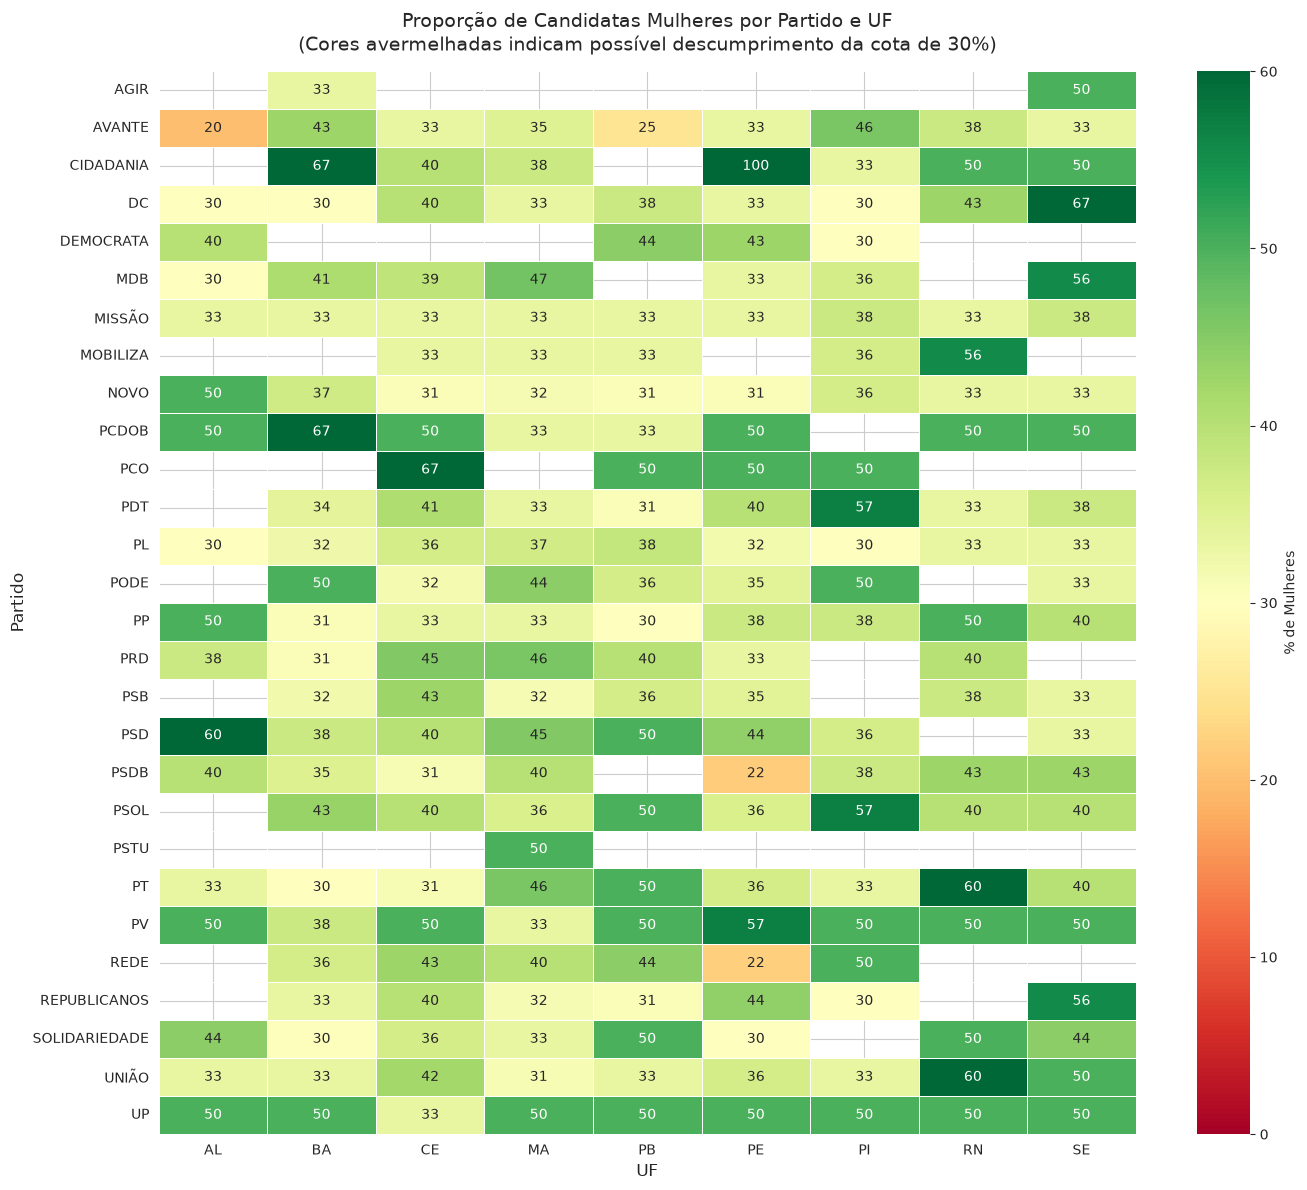

In [42]:
resumo_genero = df[df['DS_GENERO'].notna()].groupby(['SG_UF', 'SG_PARTIDO', 'DS_GENERO']).size().unstack(fill_value=0)

# Calcular o total e a porcentagem de mulheres
resumo_genero['TOTAL'] = resumo_genero.sum(axis=1)
resumo_genero['pct_mulheres'] = (resumo_genero.get('FEMININO', 0) / resumo_genero['TOTAL']) * 100

# Resetar o index para poder pivotar a tabela
df_heatmap = resumo_genero.reset_index()

# Criar a matriz Estado (colunas) x Partido (linhas)
pivot_mulheres = df_heatmap.pivot(index='SG_PARTIDO', columns='SG_UF', values='pct_mulheres')

# Plotar o Heatmap
fig, ax = plt.subplots(figsize=(14, 12))

# Usar um colormap divergente onde o centro (30%) divide cores quentes (ruim) e frias/verdes (bom)
sns.heatmap(pivot_mulheres, cmap='RdYlGn', center=30, vmin=0, vmax=60,
            annot=True, fmt=".0f", linewidths=.5, ax=ax,
            cbar_kws={'label': '% de Mulheres'})

ax.set_title('Proporção de Candidatas Mulheres por Partido e UF\n(Cores avermelhadas indicam possível descumprimento da cota de 30%)',
fontsize=14, pad=15)
ax.set_ylabel('Partido', fontsize=12)
ax.set_xlabel('UF', fontsize=12)

plt.tight_layout()
plt.show()

In [43]:

partidos_menos_30pct = df_heatmap[(df_heatmap['TOTAL'] >= 5) & (df_heatmap['pct_mulheres'] < 30)].copy()
partidos_menos_30pct = partidos_menos_30pct[['SG_UF', 'SG_PARTIDO', 'TOTAL', 'FEMININO', 'pct_mulheres']]
partidos_menos_30pct = partidos_menos_30pct.sort_values('pct_mulheres')

print("Partidos/Estados com mais de 5 candidatos que não atingiram a cota de 30%:\n")
display(partidos_menos_30pct)

Partidos/Estados com mais de 5 candidatos que não atingiram a cota de 30%:



DS_GENERO,SG_UF,SG_PARTIDO,TOTAL,FEMININO,pct_mulheres
0,AL,AVANTE,5,1,20.00
130,PE,PSDB,23,5,21.74
134,PE,REDE,9,2,22.22
91,PB,AVANTE,12,3,25.00


Observação: Ao aprofundarmos a análise para o nível partidário, percebemos que a média estadual positiva mascara o descumprimento da lei por diversos diretórios individuais. O destaque negativo vai para Pernambuco (PE). Como vimos no gráfico macro, PE já apresentava a menor proporção agregada de candidatas no Nordeste. A visão granular cruzando Partido x UF explica exatamente o porquê: Pernambuco é o estado com a maior frequência de partidos que lançaram chapas sem atingir a cota mínima de 30% exigida por lei.

---
## Fechamento

Este notebook não teve o objetivo de "preparar terreno" para nenhuma técnica específica — foi só olhar para os dados. Antes de seguir, escrevam algumas observações próprias: quais variáveis têm mais outliers? Alguma proporção chamou atenção? Alguma dispersão sugere relação entre variáveis (ou ausência dela)? Essas observações são o ponto de partida — não a conclusão — das próximas fases.

## Próximo passo

**Fase 2 — Clusterização** (K-Means, DBSCAN, hierárquico e Bisecting K-Means) — liberada em breve. A escolha de variáveis para essa fase parte do que vocês observaram aqui.